# 🗄️ Tradução de Linguagem Natural para SQL
### Projeto de Processamento de Linguagem Natural

**Arquitetura:** Encoder–Decoder com LSTM + Mecanismo de Atenção  
**Tarefa:** Text-to-SQL em Português  
**Datasets:** Spider-Test-Portuguese · C4AI Portuguese Text-to-SQL

---

## Sumário
1. [Instalação e Imports](#1-instalação-e-imports)
2. [Configurações Globais](#2-configurações-globais)
3. [Carregamento dos Datasets](#3-carregamento-dos-datasets)
4. [Análise Exploratória dos Dados (EDA)](#4-análise-exploratória-eda)
5. [Pipeline de Pré-processamento](#5-pipeline-de-pré-processamento)
6. [Construção do Vocabulário](#6-construção-do-vocabulário)
7. [Dataset e DataLoader (PyTorch)](#7-dataset-e-dataloader)
8. [Arquitetura do Modelo](#8-arquitetura-do-modelo)

---
## 1. Instalação e Imports

In [4]:
# ── Instalar dependências 
import sys
!{sys.executable} -m pip install -q torch torchtext datasets sacrebleu nltk pandas matplotlib seaborn tqdm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ── Imports padrão ─────────────────────────────────────────────────────────────
import os
import re
import json
import random
import unicodedata
from pathlib import Path
from collections import Counter
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ── PyTorch ────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ── NLP / Avaliação ────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from sacrebleu.metrics import BLEU

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

PyTorch 2.8.0+cpu | CUDA: False


---
## 2. Configurações Globais

In [6]:
# ── Reprodutibilidade ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# ── Tokens especiais ───────────────────────────────────────────────────────────
PAD_TOKEN = '<PAD>'   # padding
SOS_TOKEN = '<SOS>'   # início de sequência
EOS_TOKEN = '<EOS>'   # fim de sequência
UNK_TOKEN = '<UNK>'   # token desconhecido

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# ── Hiperparâmetros ────────────────────────────────────────────────────────────
CFG = {
    # Dados
    'max_src_len'    : 60,    # comprimento máximo da pergunta (tokens)
    'max_tgt_len'    : 80,    # comprimento máximo da query SQL (tokens)
    'min_freq'       : 1,     # frequência mínima para entrar no vocabulário
    'val_split'      : 0.1,   # fração de validação

    # Modelo
    'embed_dim'      : 256,   # dimensão dos embeddings
    'hidden_dim'     : 512,   # dimensão das células LSTM
    'num_layers'     : 2,     # número de camadas LSTM
    'dropout'        : 0.3,

    # Treinamento
    'batch_size'     : 64,
    'learning_rate'  : 3e-4,
    'num_epochs'     : 30,
    'clip_grad'      : 1.0,   # gradient clipping
    'teacher_forcing': 0.5,   # probabilidade de teacher forcing

    # I/O
    'checkpoint_dir' : './checkpoints',
}

Path(CFG['checkpoint_dir']).mkdir(exist_ok=True)
print("Configurações carregadas.")

Dispositivo: cpu
Configurações carregadas.


---
## 3. Carregamento dos Datasets

Serão utilizados dois datasets:
- **Spider-Test-Portuguese** (HuggingFace: `Boakpe/spider-test-portuguese`)
- **C4AI Portuguese Text-to-SQL** (GitHub: `C4AI/Integrating-Question-Answering-and-Text-to-SQL-in-Portuguese`)

In [ ]:
from datasets import load_dataset

# ── Spider-Test-Portuguese (HuggingFace) ──
print("Carregando Spider-Test-Portuguese...")
spider_pt = load_dataset("Boakpe/spider-test-portuguese", trust_remote_code=True)
print(spider_pt)
print("\nExemplo:")
#print(spider_pt['train'][0])

print(spider_pt.keys())
print(spider_pt[list(spider_pt.keys())[0]][0])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Boakpe/spider-test-portuguese' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Carregando Spider-Test-Portuguese...
DatasetDict({
    test: Dataset({
        features: ['db_id', 'query', 'query_toks', 'query_toks_no_value', 'question', 'question_toks', 'sql'],
        num_rows: 2147
    })
})

Exemplo:
dict_keys(['test'])
{'db_id': 'soccer_3', 'query': 'SELECT count(*) FROM club', 'query_toks': ['SELECT', 'count', '(', '*', ')', 'FROM', 'club'], 'query_toks_no_value': ['select', 'count', '(', '*', ')', 'from', 'club'], 'question': 'Quantos clubes existem?', 'question_toks': ['Quantos', 'clubes', 'existem', '?'], 'sql': {'from': {'table_units': [['table_unit', 0]], 'conds': []}, 'select': [False, [[3, [0, [0, 0, False], None]]]], 'where': [], 'groupBy': [], 'having': [], 'orderBy': [], 'limit': None, 'intersect': None, 'union': None, 'except': None}}


In [11]:
SPLIT = 'test'
QUESTION_COL = 'question'
QUERY_COL = 'query'

df_spider = pd.DataFrame({
    'question': spider_pt[SPLIT][QUESTION_COL],
    'query'   : spider_pt[SPLIT][QUERY_COL],
    'source'  : 'spider_pt'
})

print(f"Registros Spider-PT: {len(df_spider)}")
df_spider.head(3)

Registros Spider-PT: 2147


,question,query,source
0,Quantos clubes existem?,SELECT count(*) FROM club,spider_pt
1,Conte o número de clubes.,SELECT count(*) FROM club,spider_pt
2,Liste o nome dos clubes em ordem alfabética as...,SELECT Name FROM club ORDER BY Name ASC,spider_pt


In [ ]:
# ──C4AI Dataset (GitHub) ──────────────────────────────────────────────────
# Clone o repositório ou baixe manualmente os arquivos JSON/CSV
# !git clone https://github.com/C4AI/Integrating-Question-Answering-and-Text-to-SQL-in-Portuguese.git

# Exemplo de carregamento — ajuste o caminho conforme o repositório
C4AI_PATH = './Integrating-Question-Answering-and-Text-to-SQL-in-Portuguese'


In [21]:
import json, re
from pathlib import Path

c4ai_records = []

for f in Path(C4AI_PATH).rglob('*.ipynb'):
    with open(f, encoding='utf-8') as fp:
        nb = json.load(fp)
    for cell in nb.get('cells', []):
        for output in cell.get('outputs', []):
            text = ''.join(output.get('text', []))
            # Extrair pares Question / Query
            matches = re.findall(r'Question:\s*(.+?)\s*Query:\s*(SELECT.+?)(?=\n.*Question:|\Z)', text, re.DOTALL)
            for question, query in matches:
                question = question.strip()
                query    = re.split(r'\n.*New request', query)[0].strip()
                if question and query:
                    c4ai_records.append({'question': question, 'query': query})

df_c4ai = pd.DataFrame(c4ai_records)
df_c4ai['source'] = 'c4ai'
print(f"Registros C4AI extraídos: {len(df_c4ai)}")
df_c4ai.head(5)

Registros C4AI extraídos: 3


,question,query,source
0,Encontre os 3 procedimentos mais caros\nWaitin...,SELECT Procedures.Name FROM Procedures ORDER B...,c4ai
1,Encontre os 3 procedimentos mais caros\nWaitin...,SELECT Procedures.Name FROM Procedures ORDER B...,c4ai
2,Quais são os nomes distintos das enfermeiras d...,SELECT DISTINCT singer.Name FROM singer WHERE ...,c4ai


In [22]:
# Limpar ruído nas perguntas do C4AI
df_c4ai['question'] = df_c4ai['question'].str.split(r'\n').str[0].str.strip()
df_c4ai['query']    = df_c4ai['query'].str.strip()
df_c4ai = df_c4ai.drop_duplicates(subset=['question', 'query']).reset_index(drop=True)

print(f"C4AI após limpeza: {len(df_c4ai)}")

# Consolidar os dois datasets
df_all = pd.concat([df_spider, df_c4ai], ignore_index=True)
df_all = df_all.dropna(subset=['question', 'query'])
df_all = df_all.drop_duplicates(subset=['question', 'query']).reset_index(drop=True)

print(f"Total de pares: {len(df_all)}")
print(df_all['source'].value_counts())
df_all.head(5)

C4AI após limpeza: 2
Total de pares: 2146
source
spider_pt    2144
c4ai            2
Name: count, dtype: int64


,question,query,source
0,Quantos clubes existem?,SELECT count(*) FROM club,spider_pt
1,Conte o número de clubes.,SELECT count(*) FROM club,spider_pt
2,Liste o nome dos clubes em ordem alfabética as...,SELECT Name FROM club ORDER BY Name ASC,spider_pt
3,"Quais são os nomes dos clubes, ordenados alfab...",SELECT Name FROM club ORDER BY Name ASC,spider_pt
4,Quais são os gerentes e capitães dos clubes?,"SELECT Manager , Captain FROM club",spider_pt


Os pares no dataset c4ai estão espalhados nos outputs dos notebook. Ai ta dificultando a coleta 

---
## 4. Análise Exploratória (EDA)

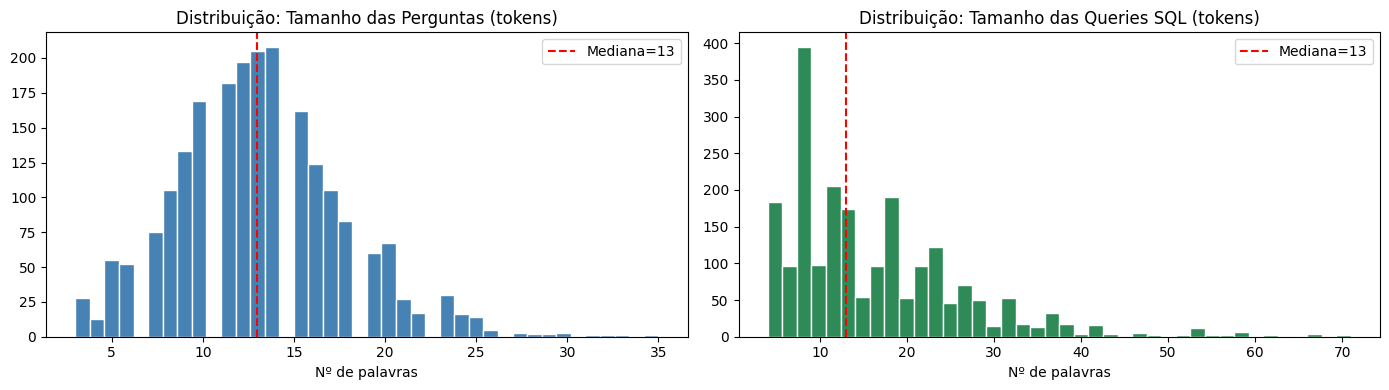

        q_len  sql_len
count  2146.0   2146.0
mean     13.0     16.3
std       4.6     10.3
min       3.0      4.0
25%      10.0      9.0
50%      13.0     13.0
75%      16.0     21.0
max      35.0     71.0


In [23]:
# ── Distribuição de comprimentos ───────────────────────────────────────────────
df_all['q_len']   = df_all['question'].apply(lambda x: len(x.split()))
df_all['sql_len'] = df_all['query'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_all['q_len'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição: Tamanho das Perguntas (tokens)')
axes[0].set_xlabel('Nº de palavras')
axes[0].axvline(df_all['q_len'].median(), color='red', linestyle='--', label=f'Mediana={df_all["q_len"].median():.0f}')
axes[0].legend()

axes[1].hist(df_all['sql_len'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Distribuição: Tamanho das Queries SQL (tokens)')
axes[1].set_xlabel('Nº de palavras')
axes[1].axvline(df_all['sql_len'].median(), color='red', linestyle='--', label=f'Mediana={df_all["sql_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df_all[['q_len', 'sql_len']].describe().round(1))

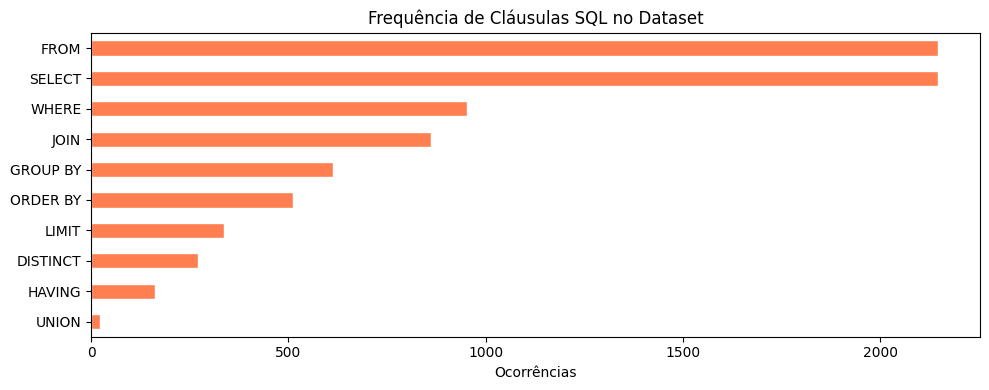

In [ ]:
# ── Palavras-chave SQL mais frequentes ──────────
SQL_KEYWORDS = ['SELECT', 'FROM', 'WHERE', 'JOIN', 'GROUP BY',
                'ORDER BY', 'HAVING', 'LIMIT', 'UNION', 'DISTINCT']

kw_counts = {kw: df_all['query'].str.upper().str.contains(kw).sum() for kw in SQL_KEYWORDS}
kw_series = pd.Series(kw_counts).sort_values(ascending=True)

kw_series.plot(kind='barh', figsize=(10, 4), color='coral', edgecolor='white')
plt.title('Frequência de Cláusulas SQL no Dataset')
plt.xlabel('Ocorrências')
plt.tight_layout()
plt.show()

---
## 5. Pipeline de Pré-processamento

In [ ]:
def normalize_text(text: str) -> str:
    """Normalização básica de texto em português."""
    text = text.strip()
    # Normalizar unicode (ex.: acentos compostos → pré-compostos)
    text = unicodedata.normalize('NFC', text)
    # Reduzir espaços múltiplos
    text = re.sub(r'\s+', ' ', text)
    return text


def tokenize_question(text: str) -> List[str]:
    """Tokeniza uma pergunta em linguagem natural."""
    text = normalize_text(text.lower())
    tokens = word_tokenize(text, language='portuguese')
    return tokens


def tokenize_sql(query: str) -> List[str]:
    """Tokeniza uma query SQL preservando operadores e literais."""
    query = normalize_text(query.upper())
    # Separar parênteses, vírgulas, operadores como tokens independentes
    query = re.sub(r'([(),;=<>!*])', r' \1 ', query)
    query = re.sub(r'>=|<=|<>|!=', lambda m: f' {m.group()} ', query)
    tokens = query.split()
    return tokens


# ── Testar o pipeline ────
sample_q   = "Quais alunos tiraram nota acima de 7 na disciplina de Cálculo?"
sample_sql = "SELECT nome FROM alunos WHERE nota > 7 AND disciplina = 'Calculo';"

print("Pergunta tokenizada:")
print(tokenize_question(sample_q))
print("\nSQL tokenizado:")
print(tokenize_sql(sample_sql))

Pergunta tokenizada:
['quais', 'alunos', 'tiraram', 'nota', 'acima', 'de', '7', 'na', 'disciplina', 'de', 'cálculo', '?']

SQL tokenizado:
['SELECT', 'NOME', 'FROM', 'ALUNOS', 'WHERE', 'NOTA', '>', '7', 'AND', 'DISCIPLINA', '=', "'CALCULO'", ';']


In [ ]:
# ── Aplicar tokenização ao dataset completo ──
print("Tokenizando dataset...")
df_all['q_tokens']   = df_all['question'].apply(tokenize_question)
df_all['sql_tokens'] = df_all['query'].apply(tokenize_sql)

# Filtrar pares que excedem o comprimento máximo
before = len(df_all)
df_all = df_all[
    (df_all['q_tokens'].apply(len)   <= CFG['max_src_len']) &
    (df_all['sql_tokens'].apply(len) <= CFG['max_tgt_len'])
].reset_index(drop=True)
after = len(df_all)

print(f"Pares removidos por exceder comprimento máximo: {before - after}")
print(f"Pares restantes: {after}")

Tokenizando dataset...
Pares removidos por exceder comprimento máximo: 0
Pares restantes: 2146


---
## 6. Construção do Vocabulário

In [ ]:
class Vocabulary:
    """Vocabulário bidirecional token ↔ índice."""

    SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

    def __init__(self, name: str, min_freq: int = 1):
        self.name = name
        self.min_freq = min_freq
        self.token2idx: Dict[str, int] = {}
        self.idx2token: Dict[int, str] = {}
        self._init_specials()

    def _init_specials(self):
        for i, tok in enumerate(self.SPECIAL_TOKENS):
            self.token2idx[tok] = i
            self.idx2token[i]   = tok

    def build_from_corpus(self, token_lists: List[List[str]]):
        counter = Counter(tok for toks in token_lists for tok in toks)
        for token, freq in counter.items():
            if freq >= self.min_freq and token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx]   = token
        print(f"Vocabulário [{self.name}]: {len(self)} tokens")

    def encode(self, tokens: List[str]) -> List[int]:
        return [self.token2idx.get(t, UNK_IDX) for t in tokens]

    def decode(self, indices: List[int]) -> List[str]:
        return [self.idx2token.get(i, UNK_TOKEN) for i in indices]

    def __len__(self) -> int:
        return len(self.token2idx)


# ── Criar e construir vocabulários ─────
src_vocab = Vocabulary('source_pt',  min_freq=CFG['min_freq'])
tgt_vocab = Vocabulary('target_sql', min_freq=CFG['min_freq'])

src_vocab.build_from_corpus(df_all['q_tokens'].tolist())
tgt_vocab.build_from_corpus(df_all['sql_tokens'].tolist())

print(f"\n10 tokens de origem mais comuns (excl. especiais):")
counter_src = Counter(t for toks in df_all['q_tokens'] for t in toks)
print(counter_src.most_common(10))

Vocabulário [source_pt]: 1514 tokens
Vocabulário [target_sql]: 1408 tokens

10 tokens de origem mais comuns (excl. especiais):
[('de', 1747), ('os', 1258), ('o', 1195), ('?', 1194), ('.', 1078), ('que', 834), ('e', 815), ('quais', 633), ('são', 611), ('dos', 601)]


---
## 7. Dataset e DataLoader (PyTorch)

In [ ]:
class Text2SQLDataset(Dataset):
    """Dataset PyTorch para pares (pergunta, SQL)."""

    def __init__(
        self,
        pairs: List[Tuple[List[str], List[str]]],
        src_vocab: Vocabulary,
        tgt_vocab: Vocabulary,
    ):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        src_tokens, tgt_tokens = self.pairs[idx]

        src_ids = self.src_vocab.encode(src_tokens)
        # Adicionar <SOS> e <EOS> à sequência alvo
        tgt_ids = [SOS_IDX] + self.tgt_vocab.encode(tgt_tokens) + [EOS_IDX]

        return torch.tensor(src_ids, dtype=torch.long), \
               torch.tensor(tgt_ids, dtype=torch.long)


def collate_fn(
    batch: List[Tuple[torch.Tensor, torch.Tensor]]
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Padding e empilhamento de sequências no batch."""
    src_seqs, tgt_seqs = zip(*batch)

    src_padded = pad_sequence(src_seqs, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD_IDX)

    src_lengths = torch.tensor([len(s) for s in src_seqs])
    tgt_lengths = torch.tensor([len(t) for t in tgt_seqs])

    return src_padded, tgt_padded, src_lengths, tgt_lengths


# ── Split treino / validação ───
pairs = list(zip(df_all['q_tokens'], df_all['sql_tokens']))
random.shuffle(pairs)

split_idx  = int(len(pairs) * (1 - CFG['val_split']))
train_pairs = pairs[:split_idx]
val_pairs   = pairs[split_idx:]

train_dataset = Text2SQLDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset   = Text2SQLDataset(val_pairs,   src_vocab, tgt_vocab)

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'],
                          shuffle=False, collate_fn=collate_fn)

print(f"Treino: {len(train_dataset)} amostras | Validação: {len(val_dataset)} amostras")

Treino: 1931 amostras | Validação: 215 amostras


---
## 8. Arquitetura do Modelo

```
Pergunta em PT → [Encoder LSTM] → context vectors
                                       ↓
                              [Attention Mechanism]
                                       ↓
                 <SOS> → [Decoder LSTM] → token₁ → token₂ → ... → <EOS>
```

In [ ]:

#  ENCODER
class Encoder(nn.Module):
    """
    Codifica a pergunta em linguagem natural em estados ocultos.
    Retorna todos os estados ocultos (para atenção) e o estado final.
    """

    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        src: torch.Tensor,           # (batch, src_len)
        src_lengths: torch.Tensor,
    ) -> Tuple[torch.Tensor, Tuple]:
        embedded = self.dropout(self.embedding(src))  # (batch, src_len, embed_dim)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        outputs, (hidden, cell) = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        # outputs: (batch, src_len, hidden_dim)
        return outputs, (hidden, cell)

In [ ]:

# MECANISMO DE ATENÇÃO (Bahdanau / Additive Attention)
class BahdanauAttention(nn.Module):
    """
    Calcula pesos de atenção entre o estado oculto do decoder
    e todos os estados do encoder.

    score(s, h) = v^T · tanh(W_s · s + W_h · h)
    """

    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W_s = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v   = nn.Linear(hidden_dim, 1,           bias=False)

    def forward(
        self,
        decoder_hidden: torch.Tensor,   # (batch, hidden_dim)  — último layer
        encoder_outputs: torch.Tensor,  # (batch, src_len, hidden_dim)
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        # Expandir decoder_hidden para comparar com cada posição do encoder
        s = decoder_hidden.unsqueeze(1).expand_as(encoder_outputs)  # (batch, src_len, hidden_dim)

        energy = self.v(torch.tanh(self.W_s(s) + self.W_h(encoder_outputs)))  # (batch, src_len, 1)
        attention_weights = F.softmax(energy.squeeze(-1), dim=1)               # (batch, src_len)

        # Vetor de contexto: soma ponderada dos estados do encoder
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)   # (batch, 1, hidden_dim)
        context = context.squeeze(1)                                            # (batch, hidden_dim)

        return context, attention_weights

In [ ]:

#  DECODER

class Decoder(nn.Module):
    """
    Gera a query SQL token a token, usando atenção sobre o encoder.
    """

    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.attention = BahdanauAttention(hidden_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(
            embed_dim + hidden_dim,   # input = embedding + context
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.fc_out = nn.Linear(hidden_dim * 2 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(
        self,
        input_token: torch.Tensor,     # (batch,)
        hidden: Tuple,
        encoder_outputs: torch.Tensor, # (batch, src_len, hidden_dim)
    ) -> Tuple[torch.Tensor, Tuple, torch.Tensor]:

        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))  # (batch, 1, embed_dim)

        decoder_hidden_top = hidden[0][-1]  # (batch, hidden_dim)
        context, attn_weights = self.attention(decoder_hidden_top, encoder_outputs)

        # Concatenar embedding + contexto → input do LSTM
        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)  # (batch, 1, embed+hidden)
        output, hidden = self.rnn(rnn_input, hidden)                    # (batch, 1, hidden)

        # Projeção final
        output   = output.squeeze(1)   # (batch, hidden)
        embedded = embedded.squeeze(1) # (batch, embed)
        logits = self.fc_out(torch.cat([output, context, embedded], dim=1))  # (batch, vocab)

        return logits, hidden, attn_weights

In [ ]:
#
#  SEQ2SEQ (Encoder + Decoder)
class Seq2Seq(nn.Module):

    def __init__(self, encoder: Encoder, decoder: Decoder, device: torch.device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(
        self,
        src: torch.Tensor,          # (batch, src_len)
        src_lengths: torch.Tensor,
        tgt: torch.Tensor,          # (batch, tgt_len)
        teacher_forcing_ratio: float = 0.5,
    ) -> torch.Tensor:

        batch_size = src.size(0)
        tgt_len    = tgt.size(1)
        vocab_size = self.decoder.fc_out.out_features

        # Tensor para armazenar as predições
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)

        # Primeiro token de entrada: <SOS>
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder.forward_step(input_token, hidden, encoder_outputs)
            outputs[:, t, :] = logits

            # Teacher forcing
            use_teacher = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if use_teacher else logits.argmax(dim=1)

        return outputs


# ── Instanciar modelo ──────
encoder = Encoder(
    vocab_size  = len(src_vocab),
    embed_dim   = CFG['embed_dim'],
    hidden_dim  = CFG['hidden_dim'],
    num_layers  = CFG['num_layers'],
    dropout     = CFG['dropout'],
)

decoder = Decoder(
    vocab_size  = len(tgt_vocab),
    embed_dim   = CFG['embed_dim'],
    hidden_dim  = CFG['hidden_dim'],
    num_layers  = CFG['num_layers'],
    dropout     = CFG['dropout'],
)

model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {n_params:,}")
print(model)

---
## 9. Treinamento

---

## Próximos Passos

| Etapa | Descrição |
|---|---|
| 🔧 Beam Search | Substituir decodificação greedy por beam search (k=3..5) |
| 📊 Exec. Accuracy | Conectar a um banco SQLite e verificar execução das queries |
| 🤗 Fine-tuning | Explorar fine-tuning de modelos pré-treinados (mT5, BART-pt) |
| 📈 Análise de erros | Categorizar e analisar os erros mais frequentes |
| 🌐 Schema-aware | Incorporar informações do schema do banco de dados na entrada |
